In [1]:
import os 
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000010D6B7E4980>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000010D6B7E5400>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [4]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt  import tools_condition,ToolNode

from langgraph.types import Command,interrupt

class State(TypedDict):
    messages : Annotated[list,add_messages]
    
graph_builder = StateGraph(State)

@tool 
def human_assistance(query:str) -> str:
    """ Request assistance from a human. """
    human_response = interrupt({"query":query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool,human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state['messages'])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
        
    return {"messages":[message]}


graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

In [5]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

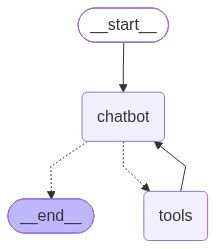

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input}, #type:ignore
    config, #type:ignore
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_9607b89f-64c2-4e42-b217-4acbe74265ab)
 Call ID: fc_9607b89f-64c2-4e42-b217-4acbe74265ab
  Args:
    query: User is seeking expert guidance and assistance for building an AI agent. Please provide detailed help and resources.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_9607b89f-64c2-4e42-b217-4acbe74265ab)
 Call ID: fc_9607b89f-64c2-4e42-b217-4acbe74265ab
  Args:
    query: User is seeking expert guidance and assistance for building an AI agent. Please provide detailed help and resources.


In [10]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values") #type:ignore
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

### Building an AI Agent – A Step‑by‑Step Guide (with LangGraph)

Below is a practical roadmap you can follow right now, plus code snippets, best‑practice tips, and a curated list of resources. It’s organized so you can pick up where you are comfortable (e.g., you already have an LLM API key, or you’re starting from scratch).

---

## 1️⃣ Define the Agent’s Purpose & Scope

| Question | Why It Matters | Example Answer |
|----------|----------------|----------------|
| **What problem am I solving?** | Determines the required tools, memory, and safety constraints. | “Help users plan a multi‑day travel itinerary with flight, hotel, and activity suggestions.” |
| **Who are the end users?** | Influences UI, latency requirements, and compliance. | “Travel‑savvy millennials using a mobile app.” |
| **What inputs & outputs?** | Shapes the prompt design and data validation. | Input: destination, dates, budget. Out